In [21]:
import os
import joblib
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,root_mean_squared_error
from sklearn.model_selection import cross_val_score
import seaborn as sns


PIPELINE_FILE="pipeline2.pkl"
MODEL_FILE="model2.pkl"
def pipeline_bulit(datas,data_label):
    num_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="mean")),
    ("standard",StandardScaler())])
    cal_pipeline=Pipeline([
    ("autoCoder",OneHotEncoder(handle_unknown="ignore")),
    ("imputer",SimpleImputer(strategy="most_frequent"))])
    full_pipeline=ColumnTransformer([
    ("num",num_pipeline,datas),
    ("cat",cal_pipeline,data_label)])
    return full_pipeline 

data = pd.read_csv("air_quality_index.csv")
data["pollution_cons"]= pd.cut(data["pollutant_avg"],bins=[0,10,20,30,40,50,np.inf],labels=[1,2,3,4,5,6])
data["pollution_cons"]=data["pollution_cons"].cat.add_categories([0])
data["pollution_cons"]=data["pollution_cons"].fillna(0)
# data["pollutant_avg"]=data["pollutant_avg"].fillna(data["pollutant_avg"].mean())
data["pollutant_avg"]=data["pollutant_avg"].ffill()

data.drop("last_update",axis=1,inplace=True)
split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index,test_index in split.split(data,data["pollution_cons"]):
    strat_train=data.loc[train_index].drop("pollution_cons",axis=1)
    strat_test=data.loc[test_index].drop("pollution_cons",axis=1)


if not os.path.exists(MODEL_FILE):
    
    datatr=strat_train.copy()
    data_label=datatr["pollutant_avg"].copy()
    datatr=datatr.drop("pollutant_avg",axis=1)
    
    datatest=strat_test.copy()
    label_test=datatest["pollutant_avg"].copy()
    datatest=datatest.drop("pollutant_avg",axis=1)
    
    num1_data=datatr.select_dtypes(include=[np.number]).columns.tolist()
    cat1_data=datatr.select_dtypes(exclude=[np.number]).columns.tolist()

    
    pipeline21=pipeline_bulit(num1_data,cat1_data)
    pollution_found=pipeline21.fit_transform(datatr)
    test_pollution=pipeline21.transform(datatest)
    
    Forest=RandomForestRegressor(max_depth=25,min_samples_leaf=5,random_state=42)
    dataset=Forest.fit(pollution_found,data_label)
    
    predict=dataset.predict(test_pollution)
    random=mean_squared_error(predict,label_test)
    
    scoring_random=cross_val_score(
    Forest,pollution_found,data_label,cv=10,scoring="neg_mean_squared_error")
    print(f"The Random Forest score is : {scoring_random}")
    print(pd.Series(scoring_random).describe())

    joblib.dump(dataset,MODEL_FILE)
    joblib.dump(pipeline21,PIPELINE_FILE)
    print("Your model is trained and fully functional")
else:
    model1=joblib.load(MODEL_FILE)
    pipeline2=joblib.load(PIPELINE_FILE)
    # input_data=pd.read_csv("air_pollution.csv")
    transform_data=pipeline2.transform(strat_test)
    prediction=model1.predict(transform_data)

    strat_test["pollution_avg"]=prediction
    strat_test.to_csv("output_air_pollution.csv",index=False)
    print("work is done with full efficeincy")
    # sns.lineplot(x=datatr["pollution_avg"].min(),y=datatr["polltuion_avg"].max())


    

    
    

work is done with full efficeincy


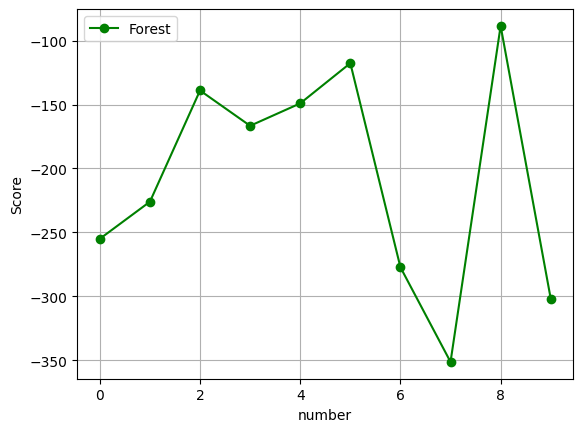

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(scoring_random,label=("Forest"),color=("green"),marker="o")


plt.legend()
plt.ylabel("Score")
plt.xlabel("number")
plt.grid()
plt.show()
plt.close()

In [16]:
from sklearn.metrics import r2_score

# print(f"Linear Regression R2 Score: {r2_score(label_test, predict1) * 100:.2f}%")
# print(f"Decision Tree R2 Score: {r2_score(label_test, predict2) * 100:.2f}%")
print(f"Random Forest R2 Score: {r2_score(label_test, predict) * 100:.2f}%")

Random Forest R2 Score: 79.14%


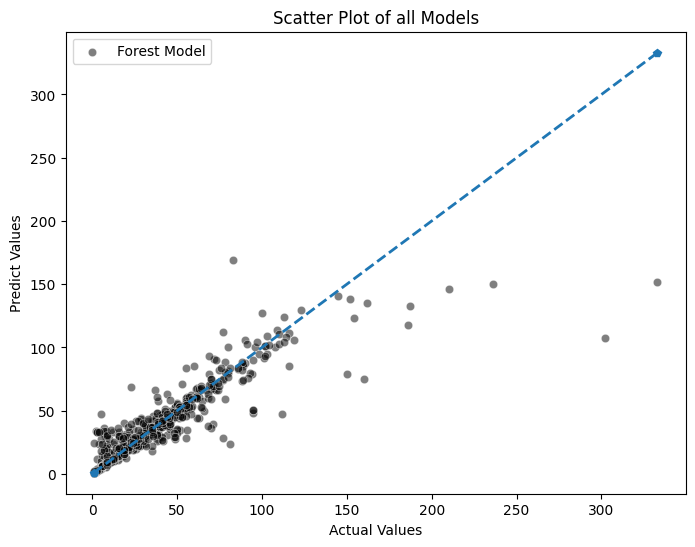

In [20]:
from sklearn.metrics import confusion_matrix
# data=confusion_matrix(label_test,predict1)

import seaborn as sns
plt.figure(figsize=(8,6))
# sns.scatterplot(x=label_test,y=predict1,label=("Linear Model"),color="red",alpha=0.5)
# sns.scatterplot(x=data_label,y=pollution_found,label=("Tree Model"),color="green",alpha=0.5)
sns.scatterplot(x=label_test,y=predict,label=("Forest Model"),color="black",alpha=0.5)
plt.plot([label_test.min(), label_test.max()], [label_test.min(), label_test.max()], 'p--', lw=2)
plt.title("Scatter Plot of all Models")
plt.xlabel("Actual Values")
plt.ylabel("Predict Values")
plt.legend()
plt.show()